<a href="https://colab.research.google.com/github/JessieGuo1/MATH5881-Tutorials/blob/main/Week9_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 9 Lab: Comparing AEs and VAEs

In this lab you will construct a variational autoencoder (VAE) for downsampled MNIST images and compare it with a deterministic nonlinear autoencoder (AE) that has the same latent dimension and decoder architecture.

The main goals are to:

1. connect the VAE evidence lower bound (ELBO) to its PyTorch implementation;
2. implement Gaussian reparameterisation and the analytic KL term;
3. train and inspect a two-dimensional VAE latent space;
4. train a comparable nonlinear AE with the same reconstruction criterion; and
5. compare latent representations of the VAE vs AE


## Notebook structure

- **Part 1:** Load and inspect the data.
- **Part 2:** Define the VAE model and ELBO.
- **Part 3:** Train the VAE.
- **Part 4:** Study Monte Carlo variability, sampling, and the VAE latent space.
- **Part 5:** Train a comparable nonlinear AE.
- **Part 6:** Compare reconstruction, generation, and latent geometry.

Set `FAST_DEMO = True` for a shorter run, but with significantly reduced quality. Set it to `False` for a more complete experiment, which will take  approx. 30mins in total runtime.

In [2]:
import itertools
import math
import os
import random
from copy import deepcopy

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from tqdm.auto import tqdm

# Reproducibility and runtime controls
SEED = 20211201
FAST_DEMO = False
RUN_TRAINING = True


def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)
torch.use_deterministic_algorithms(False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## PART 1. Load and inspect the MNIST data

The original MNIST images have size $28\times 28$. We will resize them to $14\times 14$ so that the experiments run more quickly. Pixel values returned by `ToTensor()` lie in $[0,1]$.

The original training set is split into a training set and a validation set. The validation set is used for model selection during training. The official MNIST test set is reserved for the final visualisations and comparisons.

In [3]:
image_size = 14
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((image_size, image_size)),
    torchvision.transforms.ToTensor(),
])

full_train_data = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_data = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

validation_size = 5_000
training_size = len(full_train_data) - validation_size
split_generator = torch.Generator().manual_seed(SEED)
train_data, validation_data = torch.utils.data.random_split(
    full_train_data,
    [training_size, validation_size],
    generator=split_generator,
)


def deterministic_subset(dataset, size, seed):
    size = min(size, len(dataset))
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:size].tolist()
    return torch.utils.data.Subset(dataset, indices)


if FAST_DEMO:
    train_data = deterministic_subset(train_data, 10_000, SEED + 1)
    validation_data = deterministic_subset(validation_data, 2_000, SEED + 2)
    test_data_for_plots = deterministic_subset(test_data, 3_000, SEED + 3)
else:
    test_data_for_plots = test_data

sample_shape = full_train_data[0][0].shape
data_dim = full_train_data[0][0].numel()
data_dims = sample_shape[-2:]

print('Training observations  :', len(train_data))
print('Validation observations:', len(validation_data))
print('Test observations      :', len(test_data))
print('Image shape            :', tuple(sample_shape))
print('Flattened dimension    :', data_dim)

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 606kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.49MB/s]

Training observations  : 55000
Validation observations: 5000
Test observations      : 10000
Image shape            : (1, 14, 14)
Flattened dimension    : 196


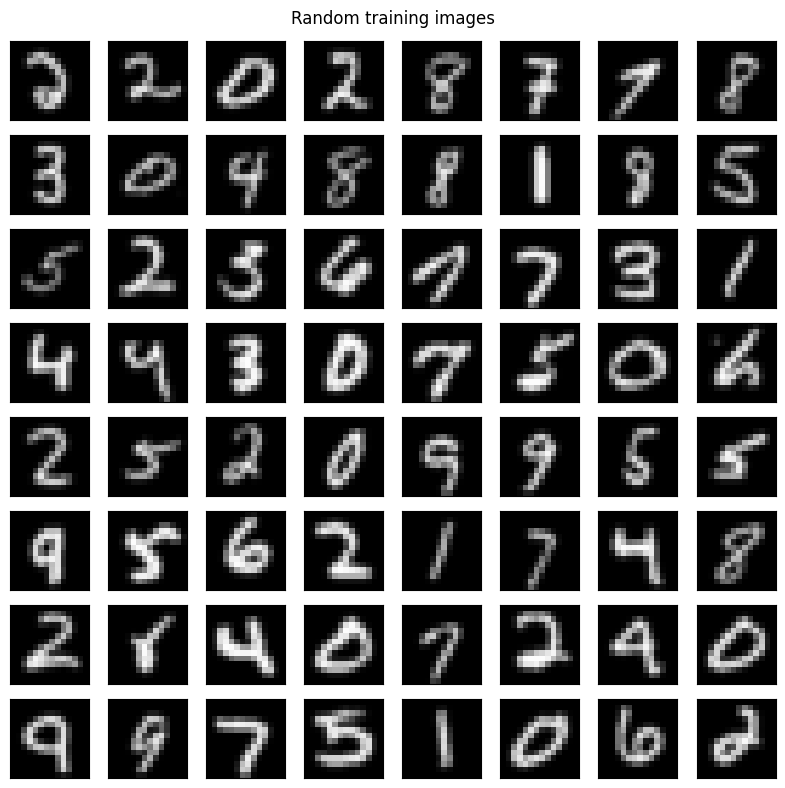

Minimum pixel value: 0.0
Maximum pixel value: 1.0


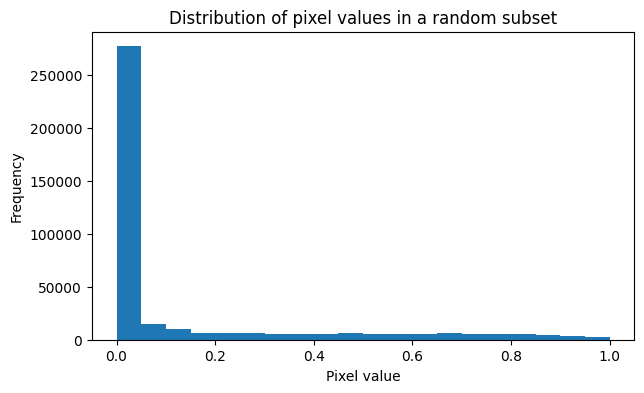

In [4]:
def plot_grid_of_mnist_samples(samples, grid=(5, 5), figsize=(8, 8), title=None):
    # Plot a batch of MNIST images stored as (N,H,W) or (N,1,H,W).
    samples = samples.detach().cpu()
    if samples.ndim == 4 and samples.shape[1] == 1:
        samples = samples[:, 0]

    rows, cols = grid
    required = rows * cols
    if len(samples) < required:
        raise ValueError(f'Need at least {required} samples, received {len(samples)}.')

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(-1)
    for idx, ax in enumerate(axes):
        ax.imshow(samples[idx], cmap='gray', vmin=0.0, vmax=1.0)
        ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
    if title is not None:
        fig.suptitle(title)
    fig.tight_layout()
    return fig


sample_indices = np.random.choice(len(train_data), size=64, replace=False)
samples = torch.stack([train_data[idx][0] for idx in sample_indices])
plot_grid_of_mnist_samples(samples, grid=(8, 8), title='Random training images')
plt.show()

# Inspect a random subset of pixel values without stacking the entire dataset.
hist_indices = np.random.choice(len(train_data), size=min(2_000, len(train_data)), replace=False)
hist_data = torch.stack([train_data[idx][0] for idx in hist_indices])
print('Minimum pixel value:', hist_data.min().item())
print('Maximum pixel value:', hist_data.max().item())

plt.figure(figsize=(7, 4))
plt.hist(hist_data.flatten().numpy(), bins=np.linspace(0, 1, 21))
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.title('Distribution of pixel values in a random subset')
plt.show()

### **Exercise 1. Choose a likelihood for the pixels**

The resized images contain many values equal to $0$ or $1$, but interpolation during resizing also creates values strictly between $0$ and $1$.

1. Why is an ordinary Bernoulli distribution not a distribution on the observed pixel space?
2. Why is a continuous Bernoulli distribution a suitable simple alternative?

## PART 2. Define the VAE model and ELBO

Let $x\in[0,1]^D$ denote a flattened image and $z\in\mathbb{R}^m$ a latent vector. The decoder outputs logits $\ell_\theta(z)\in\mathbb{R}^D$ and

$$\eta_\theta(z)=\text{sigmoid}(\ell_\theta(z)). $$

The factorised continuous Bernoulli likelihood is

$$
p_\theta(x\mid z)
=
\prod_{d=1}^D
C(\eta_d)\eta_d^{x_d}(1-\eta_d)^{1-x_d},
$$

where

$$
C(\eta)=
\begin{cases}
\dfrac{\log(\eta)-\log(1-\eta)}{2\eta-1}, & \eta\neq \tfrac12,\\[6pt]
2, & \eta=\tfrac12.
\end{cases}
$$

We use the standard Gaussian prior

$$
p(z)= N(z;0,I_m)
$$

and a diagonal Gaussian variational distribution

$$
q_\phi(z\mid x)
=
N\!\left(z;\mu_\phi(x),
\operatorname{diag}(\sigma_\phi^2(x))\right).
$$

The encoder outputs the mean and log-variance,

$$
\gamma_\phi(x)=\log \sigma_\phi^2(x),
\qquad
\sigma_\phi(x)=\exp\!\left(\tfrac12\gamma_\phi(x)\right).
$$

For one observation, the ELBO is

$$
 L(x;\theta,\phi)
=
\mathbb E_{q_\phi(z\mid x)}[\log p_\theta(x\mid z)]
-
\operatorname{KL}\!\left(q_\phi(z\mid x)\,\|\,p(z)\right).
$$

In [5]:
def evaluate_logprob_continuous_bernoulli(X, *, logits):
    # Return log p(X | logits), summed over the final pixel dimension.
    distribution = torch.distributions.ContinuousBernoulli(logits=logits)
    return distribution.log_prob(X).sum(dim=-1)


def evaluate_logprob_diagonal_gaussian(Z, *, mean, logvar):
    # Return a diagonal-Gaussian log density, summed over latent dimensions.
    distribution = torch.distributions.Normal(
        loc=mean,
        scale=torch.exp(0.5 * logvar),
    )
    return distribution.log_prob(Z).sum(dim=-1)

### **Exercise 2. Implement the analytic Gaussian KL divergence**

For

$$
q(z\mid x)= N(z;\mu,\operatorname{diag}(\sigma^2))
\quad\text{and}\quad
p(z)= N(z;0,I),
$$

we know that

$$
\operatorname{KL}(q\|p)
=
-\frac12\sum_{k=1}^K
\left(1+\log\sigma_k^2-\mu_k^2-\sigma_k^2\right),
$$

Implement this calculation in a function called  `compute_kld_with_standard_gaussian` below

In [6]:
def compute_kld_with_standard_gaussian(q_mean, q_logvar):
    # Compute KL(q(z|x) || N(0,I)) for each observation in a batch.
    return -0.5 * (1 + q_logvar - q_mean**2 - torch.exp(q_logvar)).sum(dim=-1)

### **Exercise 3. Implement Gaussian reparameterisation**

A diagonal Gaussian sample can be written as

$$
\epsilon\sim N(0,I),
\qquad
z=\mu+\sigma\odot\epsilon.
$$

Implement this transformation without calling `Normal.rsample()`.

In [7]:
def sample_gaussian_with_reparametrisation(mean, logvar, *, num_samples=1):
    # Return samples with shape (num_samples, batch_size, latent_dim).
    epsilon = torch.randn(
        (num_samples,) + mean.shape,
        device=mean.device,
        dtype=mean.dtype,
    )
    return mean + torch.exp(0.5 * logvar) * epsilon, (mean + torch.exp(0.5 * logvar) * epsilon).shape


### **Exercise 4. Implement the Monte Carlo ELBO**

Use $M$ reparameterised samples to approximate

$$
\mathbb E_{q_\phi(z\mid x)}[\log p_\theta(x\mid z)]
\approx
\frac1M\sum_{j=1}^M \log p_\theta(x\mid z^{(j)}).
$$

The analytic KL term is subtracted once for each observation.

In [8]:
def elbo_with_pathwise_gradients(X, *, encoder, decoder, num_samples):
    # Evaluate one Monte Carlo ELBO estimate for each observation in X.
    mean, logvar = encoder(X)
    Z, _ = sample_gaussian_with_reparametrisation(mean, logvar, num_samples=num_samples)
    logits = decoder(Z)

    # Calculate expected log likelihood term
    log_prob_x_given_z = evaluate_logprob_continuous_bernoulli(X, logits=logits)
    expected_log_likelihood = log_prob_x_given_z.mean(dim=0)  # Average over samples

    return expected_log_likelihood

### **Exercise 5. Explain the pathwise gradient**

After reparameterisation, write the reconstruction expectation as

$$
\mathbb E_{\epsilon\sim  N(0,I)}
\left[
\log p_\theta\!\left(x\mid t_\phi(x,\epsilon)\right)
\right],
\qquad
t_\phi(x,\epsilon)=\mu_\phi(x)+\sigma_\phi(x)\odot\epsilon.
$$

Explain why this allows automatic differentiation with respect to both $\theta$ and $\phi$.



Reparameterisation separates the randomness from the encoder parameters. The randomness is only in ϵ, which does not depend on ϕ. Once we sample ϵ, the latent variable z is a deterministic differentiable function of ϕ. So automatic differentiation can compute gradients through this whole path. For θ, this is straightforward because θ appears directly in the decoder likelihood:

### Construct the encoder, decoder, and VAE wrapper

The encoder takes the D dimensional flattened image vector to a hidden layer with 100 units and then produces parameters of dimension $m$. The encoder has separate output heads for the mean and log-variance. That is,

$$
D\longrightarrow 100\longrightarrow m
$$

and the decoder performs,
$$
m\longrightarrow 100\longrightarrow D
$$

The decoder returns unconstrained logits for the continuous Bernoulli likelihood.

In [9]:
class Encoder(nn.Module):
    # Inference network q_phi(z | x).

    def __init__(self, data_dim, hidden_dim, latent_dim):
        super().__init__()

        self.features = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

    def forward(self, X):
        features = self.features(X)
        return self.mean_head(features), self.logvar_head(features)


class ContinuousBernoulliDecoder(nn.Module):
    # Generative network p_theta(x | z), returning likelihood logits.

    def __init__(self, latent_dim, hidden_dim, data_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def forward(self, Z):
        return self.network(Z)

    @staticmethod
    def distribution(logits):
        return torch.distributions.ContinuousBernoulli(logits=logits)

    def sample(self, logits, *, num_samples=1):
        return self.distribution(logits).sample((num_samples,))

    def mean(self, logits):
        return self.distribution(logits).mean

    def parameter(self, logits):
        return self.distribution(logits).probs


class VAE(nn.Module):
    # VAE wrapper that returns a per-observation ELBO.

    def __init__(self, data_dim, hidden_dim=100, latent_dim=2, num_variational_samples=1):
        super().__init__()
        self.encoder = Encoder(data_dim, hidden_dim, latent_dim)
        self.decoder = ContinuousBernoulliDecoder(latent_dim, hidden_dim, data_dim)
        self.num_variational_samples = num_variational_samples

    def forward(self, X):
        return elbo_with_pathwise_gradients(
            X,
            encoder=self.encoder,
            decoder=self.decoder,
            num_samples=self.num_variational_samples,
        )


# Shape check with synthetic inputs.
shape_check_model = VAE(data_dim=data_dim, hidden_dim=100, latent_dim=2)
shape_check_X = torch.rand(8, data_dim)
shape_check_elbo = shape_check_model(shape_check_X)
assert shape_check_elbo.shape == (8,)

### **Exercise 6.**

1. What does `Encoder.forward()` return?
2. What does `ContinuousBernoulliDecoder.forward()` return?
3. Why does the decoder not apply a sigmoid in its `forward()` method?



1. learns the mean and log variance -- $\mu_\phi(x)$, log$\sigma^2_\phi(x)$

2. likelihood logits given latent samples $(Z)$ -- outputs raw real-values numbers, before it is transformed

3. the logits are passed directly into torch.distributions.ContinuousBernoulli(logits=logits)


## PART 3. Train the VAE

The optimiser minimises a loss, whereas the VAE objective is maximised. We therefore use the negative mini-batch mean ELBO as the loss.

The model checkpoint is selected using the validation ELBO, not the test set. The official test set remains untouched during model fitting.

In [10]:
def flatten_images(X):
    return X.view(X.shape[0], -1)


def create_dataloader(dataset, *, batch_size, shuffle):
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(device.type == 'cuda'),
    )


@torch.inference_mode()
def average_vae_elbo(model, loader):
    model.eval()
    total_elbo = 0.0
    total_count = 0
    for X, _ in loader:
        X = flatten_images(X.to(device))
        elbos = model(X)
        total_elbo += elbos.sum().item()
        total_count += len(X)
    return total_elbo / total_count


def fit_vae(model, optimizer, train_dataset, validation_dataset, *, batch_size, epochs):
    train_loader = create_dataloader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = create_dataloader(validation_dataset, batch_size=batch_size, shuffle=False)

    history = {
        'epoch': [],
        'train_elbo': [],
        'validation_elbo': [],
    }

    best_validation_elbo = float('-inf')
    best_model_state = None
    best_optimizer_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_elbo = 0.0
        total_count = 0

        progress = tqdm(train_loader, leave=False, desc=f'VAE epoch {epoch}/{epochs}')
        for X, _ in progress:
            X = flatten_images(X.to(device))

            optimizer.zero_grad(set_to_none=True)
            elbos = model(X)
            loss = -elbos.mean()
            loss.backward()
            optimizer.step()

            total_train_elbo += elbos.detach().sum().item()
            total_count += len(X)
            progress.set_postfix(elbo=f'{elbos.mean().item():.2f}')

        train_elbo = total_train_elbo / total_count
        validation_elbo = average_vae_elbo(model, validation_loader)

        history['epoch'].append(epoch)
        history['train_elbo'].append(train_elbo)
        history['validation_elbo'].append(validation_elbo)

        if validation_elbo > best_validation_elbo:
            best_validation_elbo = validation_elbo
            best_model_state = deepcopy(model.state_dict())
            best_optimizer_state = deepcopy(optimizer.state_dict())

        print(
            f'Epoch {epoch:02d}: train ELBO = {train_elbo:.3f}, '
            f'validation ELBO = {validation_elbo:.3f}'
        )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        optimizer.load_state_dict(best_optimizer_state)

    return model, optimizer, history


def save_checkpoint(model, optimizer, path):
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        },
        path,
    )


def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return model, optimizer

### **Exercise 7. Instantiate and train the VAE**

Use the same latent dimension and hidden width later used by the nonlinear AE. Train with one variational sample per observation.

Fill out the values for the appropriate hyperparameters below.

In [19]:
# Complete hyperparameter selection:
latent_dim = 2
hidden_dim =16
batch_size =16
epochs = 5 if FAST_DEMO else 20
learning_rate = 3e-3

In [20]:
seed_everything(SEED)
vae_model = VAE(
    data_dim=data_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    num_variational_samples=1,
).to(device)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=learning_rate)

vae_checkpoint_path = 'vae_checkpoint.pt'
vae_history_path = 'vae_history.pt'

if RUN_TRAINING or not os.path.exists(vae_checkpoint_path):
    vae_model, vae_optimizer, vae_history = fit_vae(
        vae_model,
        vae_optimizer,
        train_data,
        validation_data,
        batch_size=batch_size,
        epochs=epochs,
    )
    save_checkpoint(vae_model, vae_optimizer, vae_checkpoint_path)
    torch.save(vae_history, vae_history_path)
else:
    vae_model, vae_optimizer = load_checkpoint(
        vae_model, vae_optimizer, vae_checkpoint_path
    )
    vae_history = torch.load(vae_history_path, map_location='cpu')

VAE epoch 1/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 01: train ELBO = 334.998, validation ELBO = 349.481


VAE epoch 2/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 02: train ELBO = 354.141, validation ELBO = 355.782


VAE epoch 3/20:   0%|          | 0/3438 [00:00<?, ?it/s]

...

Epoch 18: train ELBO = 364.059, validation ELBO = 362.974


VAE epoch 19/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 19: train ELBO = 364.115, validation ELBO = 363.244


VAE epoch 20/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 20: train ELBO = 364.205, validation ELBO = 363.219


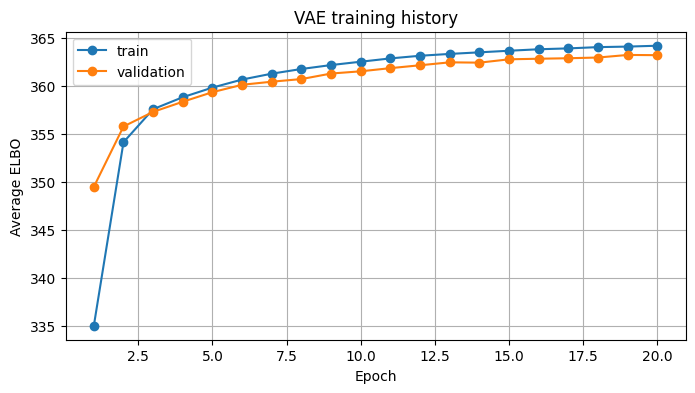

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(vae_history['epoch'], vae_history['train_elbo'], marker='o', label='train')
plt.plot(
    vae_history['epoch'],
    vae_history['validation_elbo'],
    marker='o',
    label='validation',
)
plt.xlabel('Epoch')
plt.ylabel('Average ELBO')
plt.title('VAE training history')
plt.grid(True)
plt.legend()
plt.show()

## PART 4. VAE diagnostics

### **Exercise 8. Effect of Monte Carlo averaging**

Hold the data and fitted model fixed. Repeatedly estimate the average ELBO of one mini-batch using $M\in\{1,5,20\}$ variational samples. Compare the empirical standard deviations.

Before running the code, predict how the standard deviation should change as $M$ increases.

M= 1: Empirical Std Dev of ELBO estimate = 0.0099
M= 5: Empirical Std Dev of ELBO estimate = 0.0042
M=20: Empirical Std Dev of ELBO estimate = 0.0022


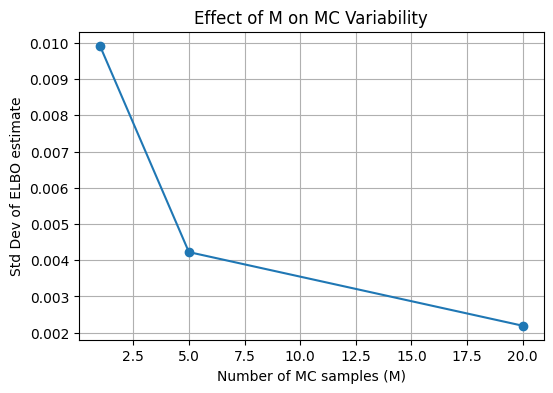

In [22]:
def estimate_batch_elbo_std(model, X, num_samples, num_repeats=100):
    model.eval()
    estimates = []
    with torch.no_grad():
        for _ in range(num_repeats):
            elbo = model(X).mean().item()
            estimates.append(elbo)
    return np.std(estimates)

# Get a single batch of data
data_loader = create_dataloader(validation_data, batch_size=batch_size, shuffle=True)
X_batch, _ = next(iter(data_loader))
X_batch = flatten_images(X_batch.to(device))

sample_sizes = [1, 5, 20]
stds = []

for M in sample_sizes:
    vae_model.num_variational_samples = M
    std = estimate_batch_elbo_std(vae_model, X_batch, M)
    stds.append(std)
    print(f'M={M:2d}: Empirical Std Dev of ELBO estimate = {std:.4f}')

# Reset model to default
vae_model.num_variational_samples = 1

plt.figure(figsize=(6, 4))
plt.plot(sample_sizes, stds, 'o-')
plt.xlabel('Number of MC samples (M)')
plt.ylabel('Std Dev of ELBO estimate')
plt.title('Effect of M on MC Variability')
plt.grid(True)
plt.show()

### **Exercise 9. Sample from the fitted VAE**

Generate $z\sim N(0,I)$ and display three different decoder outputs:

1. a random draw $x\sim p_\theta(x\mid z)$;
2. the conditional mean $\mathbb E[x\mid z]$; and
3. the continuous Bernoulli parameter $\eta_\theta(z)$.

Explain why these are different.


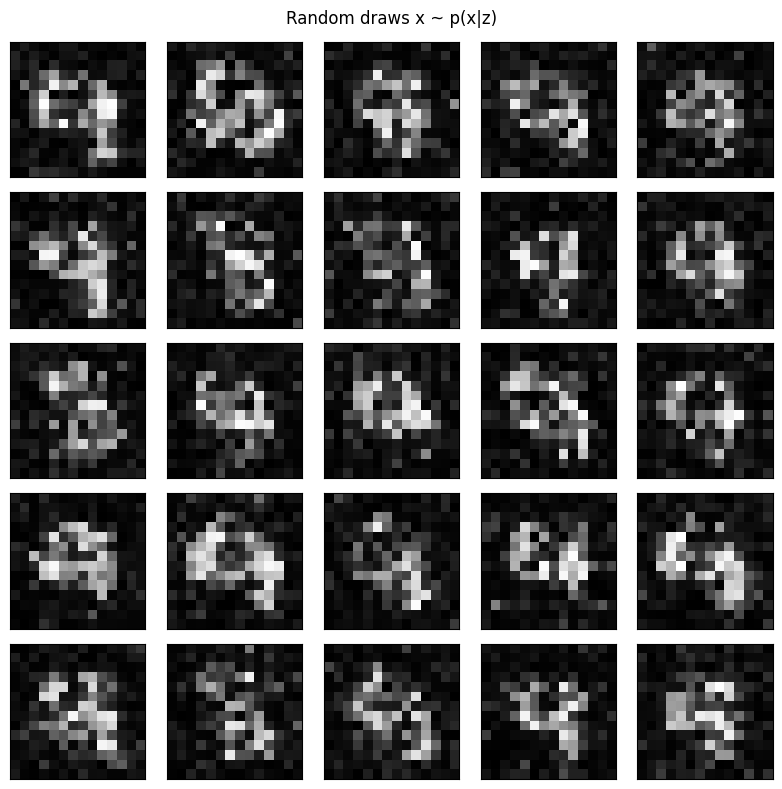

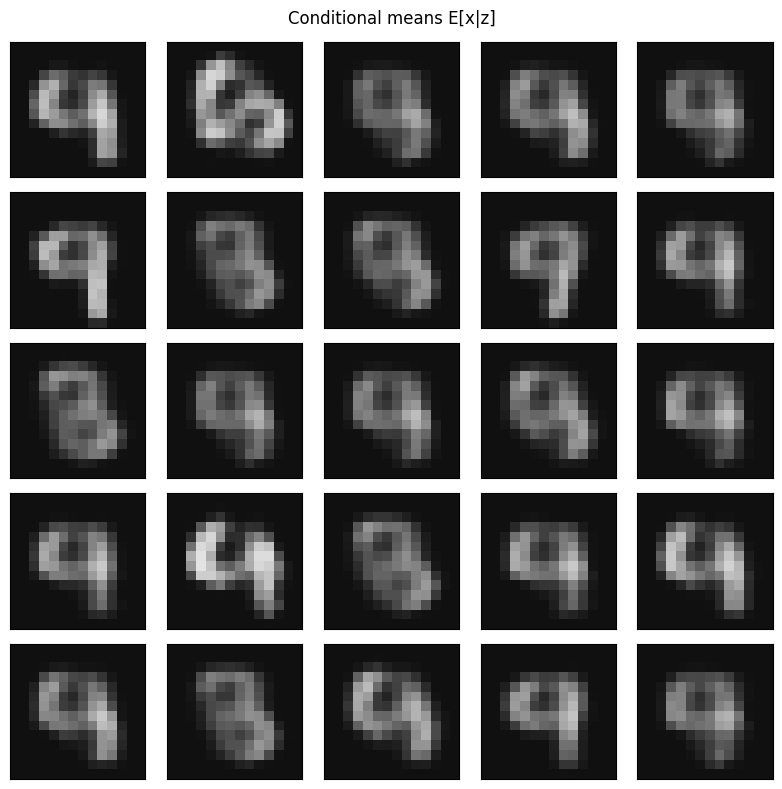

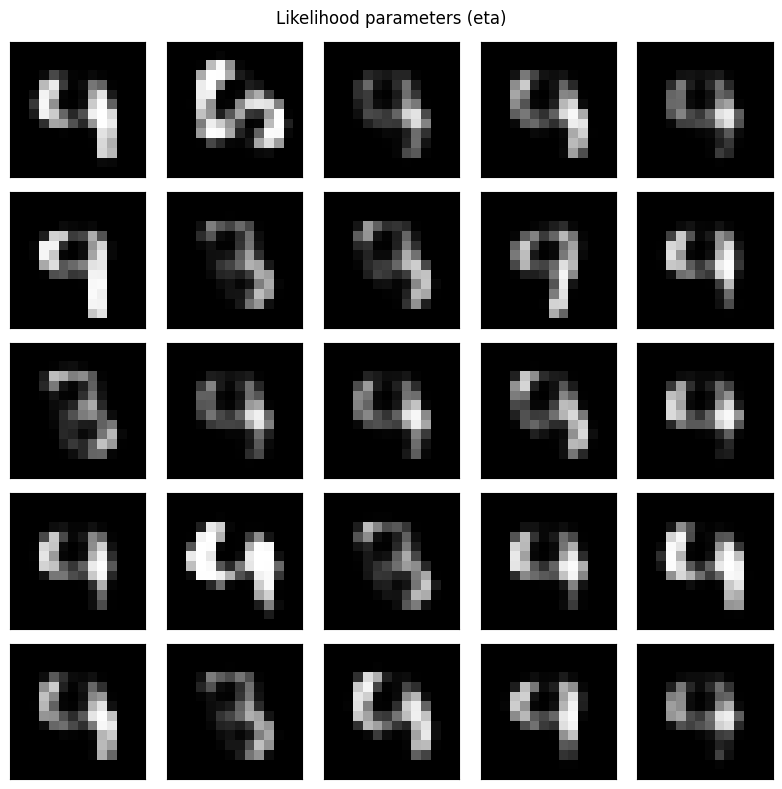

In [23]:
# Exercise 9: Sample from the fitted VAE
seed_everything(SEED + 42)
num_gen = 25
z_samples = torch.randn(num_gen, latent_dim).to(device)

with torch.no_grad():
    logits = vae_model.decoder(z_samples)

    # 1. A random draw x ~ p(x|z)
    random_draws = vae_model.decoder.sample(logits).view(-1, *data_dims)

    # 2. The conditional mean E[x|z]
    cond_means = vae_model.decoder.mean(logits).view(-1, *data_dims)

    # 3. The Continuous Bernoulli parameter (probabilities)
    params = vae_model.decoder.parameter(logits).view(-1, *data_dims)

plot_grid_of_mnist_samples(random_draws, title='Random draws x ~ p(x|z)')
plot_grid_of_mnist_samples(cond_means, title='Conditional means E[x|z]')
plot_grid_of_mnist_samples(params, title='Likelihood parameters (eta)')
plt.show()

### **Exercise 10. Inspect the VAE latent space**

The following code projects test images to the two-dimensional latent space using the encoder mean. It then decodes a regular grid of latent values in $[-3,3]^2$.

What structure do you expect to see, given that digit labels were never used during training?


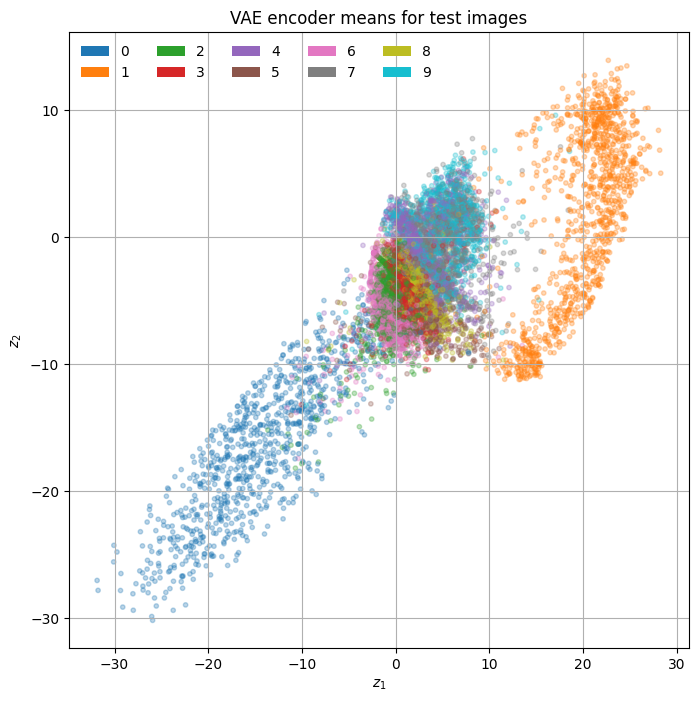

In [24]:
@torch.inference_mode()
def encode_dataset_with_vae(model, dataset, *, batch_size):
    loader = create_dataloader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    latent_means = []
    labels = []
    for X, y in loader:
        X = flatten_images(X.to(device))
        mean, _ = model.encoder(X)
        latent_means.append(mean.cpu())
        labels.append(y.cpu())
    return torch.cat(latent_means), torch.cat(labels)


Z_vae, Y_test = encode_dataset_with_vae(
    vae_model, test_data_for_plots, batch_size=batch_size
)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
point_colors = np.asarray(colors)[Y_test.numpy()]

plt.figure(figsize=(8, 8))
plt.scatter(Z_vae[:, 0], Z_vae[:, 1], c=point_colors, alpha=0.30, s=10)
legend_elements = [mpl.patches.Patch(facecolor=colors[i], label=str(i)) for i in range(10)]
plt.legend(handles=legend_elements, ncol=5, frameon=False)
plt.xlabel(r'$z_1$')
plt.ylabel(r'$z_2$')
plt.title('VAE encoder means for test images')
plt.grid(True)
plt.show()

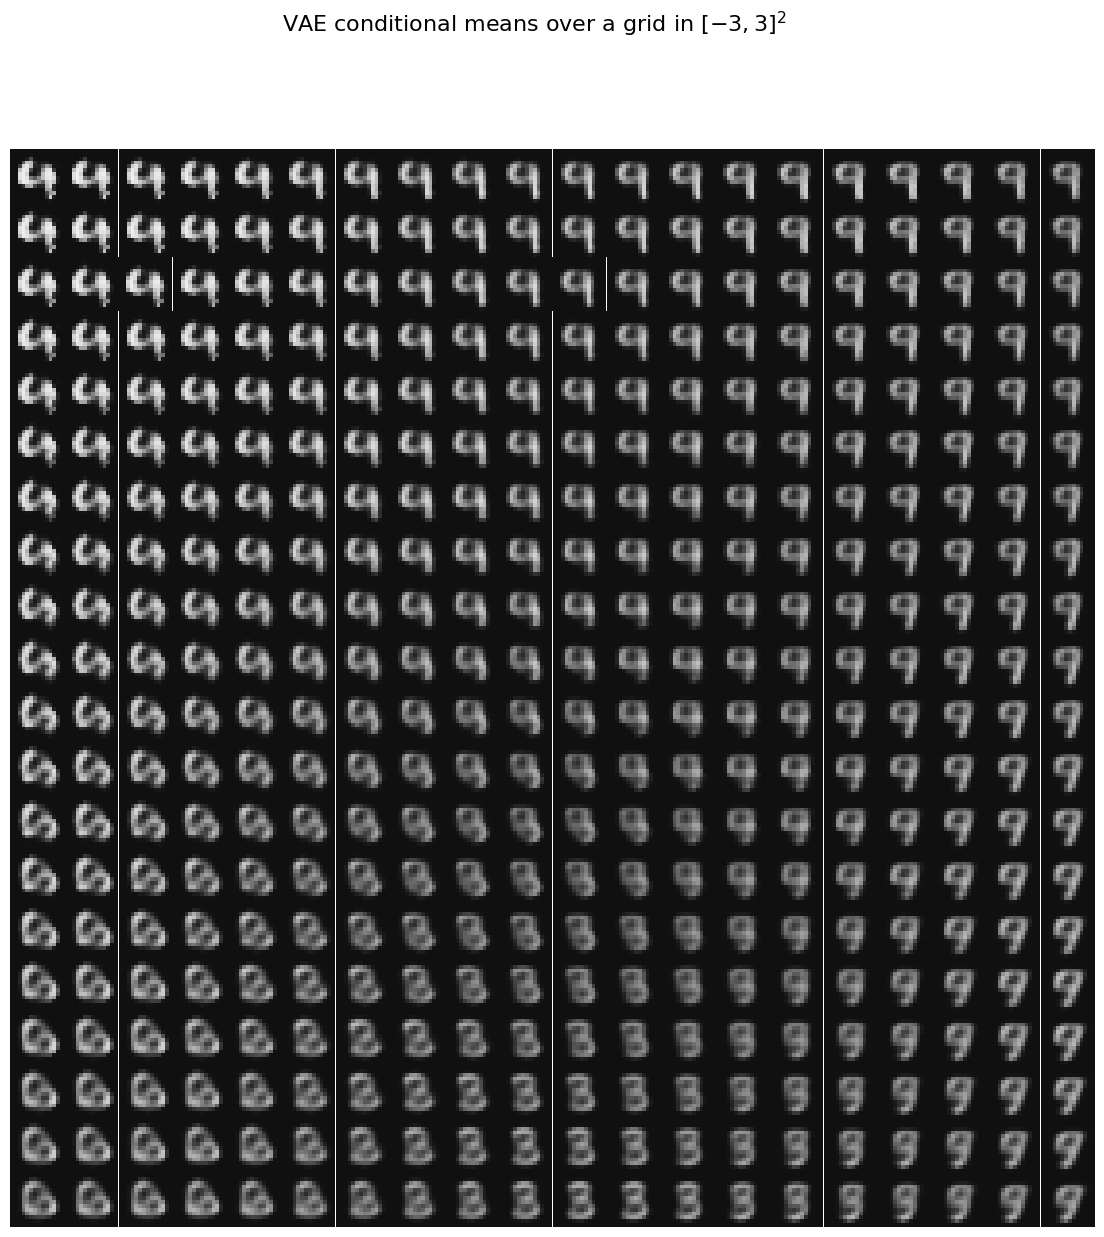

In [28]:
steps = 20
grid_values = torch.linspace(-3.0, 3.0, steps, device=device)
z1, z2 = torch.meshgrid(grid_values, grid_values, indexing='ij')
Z_grid = torch.stack([z1.reshape(-1), z2.reshape(-1)], dim=-1)

with torch.inference_mode():
    grid_logits = vae_model.decoder(Z_grid)
    grid_means = vae_model.decoder.mean(grid_logits).cpu().view(
        steps, steps, *data_dims
    )

fig, axes = plt.subplots(steps, steps, figsize=(14, 14))
fig.subplots_adjust(wspace=0.0, hspace=0.0)
for i, j in itertools.product(range(steps), range(steps)):
    axes[steps - j - 1, i].imshow(grid_means[i, j], cmap='gray', vmin=0, vmax=1)
    axes[steps - j - 1, i].axis('off')
fig.suptitle(r'VAE conditional means over a grid in $[-3,3]^2$', fontsize=16)
plt.show()

## PART 5. Train a comparable nonlinear autoencoder

The deterministic AE uses the same dimensions

$$
D\longrightarrow 100\longrightarrow 2\longrightarrow 100\longrightarrow D.
$$

To make the comparison cleaner, it is trained with the **same continuous Bernoulli reconstruction criterion** as the VAE. The key differences are:

- the AE uses one deterministic latent code $z=g_\psi(x)$;
- the AE has no variational distribution; and
- the AE has no KL term encouraging its encoded points to follow a known prior.

### Define and train the nonlinear AE

Complete the model and training loop. The decoder must return logits, and the loss is the negative continuous Bernoulli log likelihood averaged over the mini-batch.

In [25]:
class NonlinearAutoencoder(nn.Module):
    #Deterministic AE with the same hidden width, latent size, and decoder form.

    def __init__(self, data_dim, hidden_dim=100, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.decoder_logits = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def encode(self, X):
        return self.encoder(X)

    def decode_logits(self, Z):
        return self.decoder_logits(Z)

    def decode_mean(self, Z):
        logits = self.decode_logits(Z)
        return torch.distributions.ContinuousBernoulli(logits=logits).mean

    def forward(self, X):
        Z = self.encode(X)
        logits = self.decode_logits(Z)
        return logits, Z


@torch.inference_mode()
def average_ae_log_likelihood(model, loader):
    model.eval()
    total_log_likelihood = 0.0
    total_count = 0
    for X, _ in loader:
        X = flatten_images(X.to(device))
        logits, _ = model(X)
        log_likelihood = evaluate_logprob_continuous_bernoulli(X, logits=logits)
        total_log_likelihood += log_likelihood.sum().item()
        total_count += len(X)
    return total_log_likelihood / total_count


def fit_autoencoder(model, optimizer, train_dataset, validation_dataset, *, batch_size, epochs):
    train_loader = create_dataloader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = create_dataloader(validation_dataset, batch_size=batch_size, shuffle=False)

    history = {
        'epoch': [],
        'train_log_likelihood': [],
        'validation_log_likelihood': [],
    }

    best_validation_log_likelihood = float('-inf')
    best_model_state = None
    best_optimizer_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_log_likelihood = 0.0
        total_count = 0

        progress = tqdm(train_loader, leave=False, desc=f'AE epoch {epoch}/{epochs}')
        for X, _ in progress:
            X = flatten_images(X.to(device))

            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(X)
            log_likelihood = evaluate_logprob_continuous_bernoulli(X, logits=logits)
            loss = -log_likelihood.mean()
            loss.backward()
            optimizer.step()

            total_log_likelihood += log_likelihood.detach().sum().item()
            total_count += len(X)
            progress.set_postfix(loglik=f'{log_likelihood.mean().item():.2f}')

        train_log_likelihood = total_log_likelihood / total_count
        validation_log_likelihood = average_ae_log_likelihood(model, validation_loader)

        history['epoch'].append(epoch)
        history['train_log_likelihood'].append(train_log_likelihood)
        history['validation_log_likelihood'].append(validation_log_likelihood)

        if validation_log_likelihood > best_validation_log_likelihood:
            best_validation_log_likelihood = validation_log_likelihood
            best_model_state = deepcopy(model.state_dict())
            best_optimizer_state = deepcopy(optimizer.state_dict())

        print(
            f'Epoch {epoch:02d}: train log likelihood = {train_log_likelihood:.3f}, '
            f'validation log likelihood = {validation_log_likelihood:.3f}'
        )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        optimizer.load_state_dict(best_optimizer_state)

    return model, optimizer, history

In [26]:
seed_everything(SEED)
ae_model = NonlinearAutoencoder(
    data_dim=data_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
).to(device)
ae_optimizer = optim.Adam(ae_model.parameters(), lr=learning_rate)

ae_checkpoint_path = 'ae_checkpoint.pt'
ae_history_path = 'ae_history.pt'

if RUN_TRAINING or not os.path.exists(ae_checkpoint_path):
    ae_model, ae_optimizer, ae_history = fit_autoencoder(
        ae_model,
        ae_optimizer,
        train_data,
        validation_data,
        batch_size=batch_size,
        epochs=epochs,
    )
    save_checkpoint(ae_model, ae_optimizer, ae_checkpoint_path)
    torch.save(ae_history, ae_history_path)
else:
    ae_model, ae_optimizer = load_checkpoint(
        ae_model, ae_optimizer, ae_checkpoint_path
    )
    ae_history = torch.load(ae_history_path, map_location='cpu')

AE epoch 1/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 01: train log likelihood = 341.683, validation log likelihood = 354.496


AE epoch 2/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 02: train log likelihood = 357.319, validation log likelihood = 358.129


AE epoch 3/20:   0%|          | 0/3438 [00:00<?, ?it/s]

...

Epoch 18: train log likelihood = 363.377, validation log likelihood = 362.361


AE epoch 19/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 19: train log likelihood = 363.427, validation log likelihood = 362.668


AE epoch 20/20:   0%|          | 0/3438 [00:00<?, ?it/s]

Epoch 20: train log likelihood = 363.492, validation log likelihood = 362.561


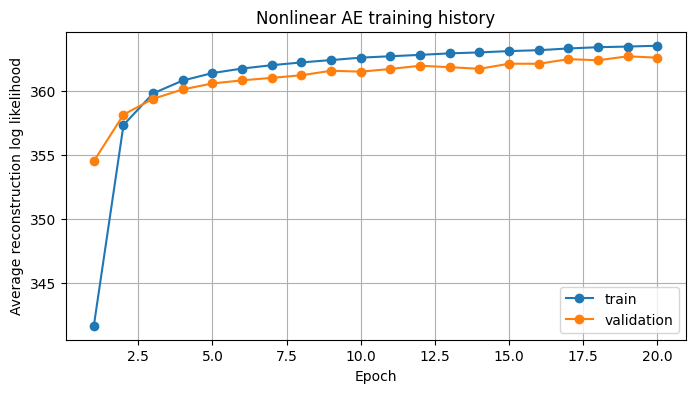

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(
    ae_history['epoch'],
    ae_history['train_log_likelihood'],
    marker='o',
    label='train',
)
plt.plot(
    ae_history['epoch'],
    ae_history['validation_log_likelihood'],
    marker='o',
    label='validation',
)
plt.xlabel('Epoch')
plt.ylabel('Average reconstruction log likelihood')
plt.title('Nonlinear AE training history')
plt.grid(True)
plt.legend()
plt.show()

## PART 6. Compare the VAE and nonlinear AE

The two models now share the same data preprocessing, latent dimension, hidden width, decoder architecture, optimiser, learning rate, number of epochs, and continuous Bernoulli reconstruction criterion. The VAE additionally has a stochastic encoder and a KL term.

### **Exercise 11a. Compare reconstructions**

For the VAE, use the encoder mean as a deterministic latent representation. Compare original images, VAE conditional-mean reconstructions, and AE conditional-mean reconstructions.

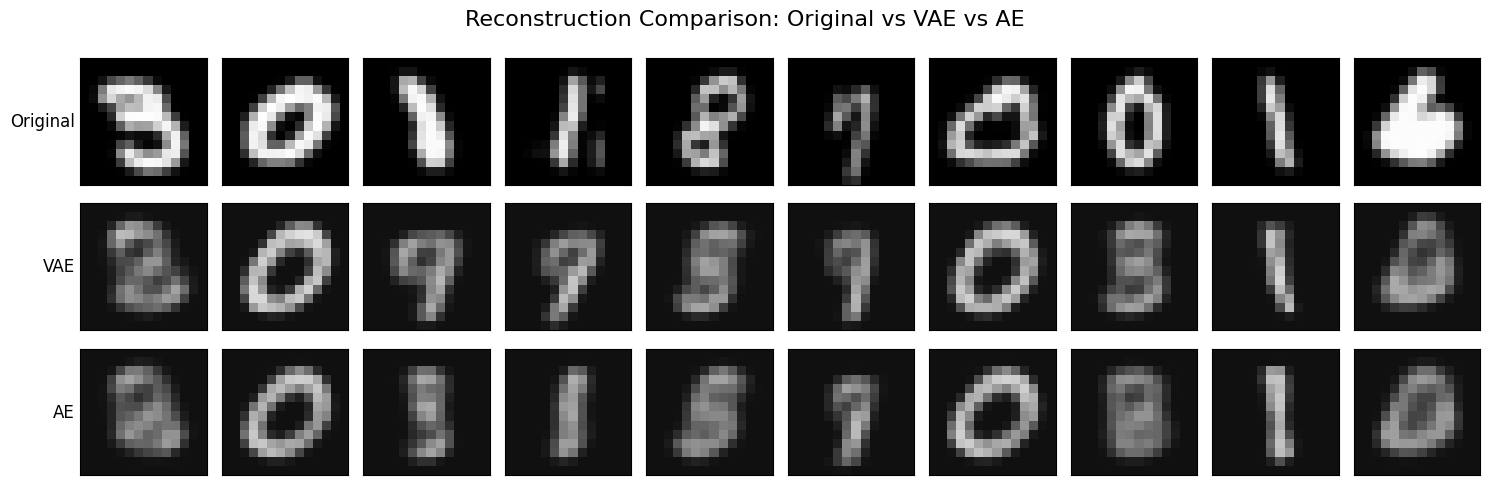

In [30]:
# Exercise 11a: Compare reconstructions
seed_everything(SEED + 7)
num_compare = 10
loader = create_dataloader(test_data, batch_size=num_compare, shuffle=True)
X_orig, _ = next(iter(loader))
X_flat = flatten_images(X_orig.to(device))

with torch.no_grad():
    # VAE Reconstructions (using encoder mean)
    vae_mean, _ = vae_model.encoder(X_flat)
    vae_logits = vae_model.decoder(vae_mean)
    vae_recon = vae_model.decoder.mean(vae_logits).cpu().view(-1, *data_dims)

    # AE Reconstructions
    ae_recon = ae_model.decode_mean(ae_model.encode(X_flat)).cpu().view(-1, *data_dims)

# Visualization
fig, axes = plt.subplots(3, num_compare, figsize=(num_compare * 1.5, 5))
for i in range(num_compare):
    # Original
    axes[0, i].imshow(X_orig[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
    # VAE
    axes[1, i].imshow(vae_recon[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
    # AE
    axes[2, i].imshow(ae_recon[i], cmap='gray', vmin=0, vmax=1)
    axes[2, i].set_xticks([]); axes[2, i].set_yticks([])

# Add row labels
axes[0, 0].set_ylabel('Original', rotation=0, ha='right', va='center', fontsize=12)
axes[1, 0].set_ylabel('VAE', rotation=0, ha='right', va='center', fontsize=12)
axes[2, 0].set_ylabel('AE', rotation=0, ha='right', va='center', fontsize=12)

plt.suptitle('Reconstruction Comparison: Original vs VAE vs AE', fontsize=16)
plt.tight_layout()
plt.show()

### **Exercise 11b. Decode the same standard-normal latent samples**

Draw one set of latent vectors $z\sim N(0,I)$ and decode exactly the same vectors with both models. Explain why the comparison is not symmetric even though the input latent vectors are identical.

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2184/1462700930.py:15: SyntaxWarning: invalid escape sequence '\s'
  plot_grid_of_mnist_samples(vae_gen, title='VAE: decoding $z \sim N(0, I)$')
/tmp/ipykernel_2184/1462700930.py:19: SyntaxWarning: invalid escape sequence '\s'
  plot_grid_of_mnist_samples(ae_gen, title='AE: decoding same $z \sim N(0, I)$')


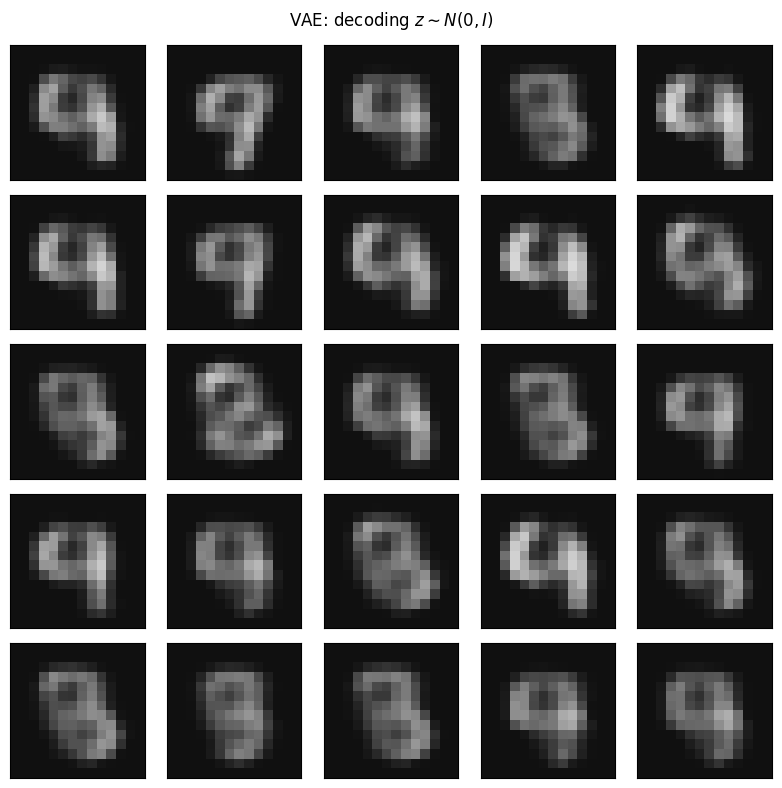

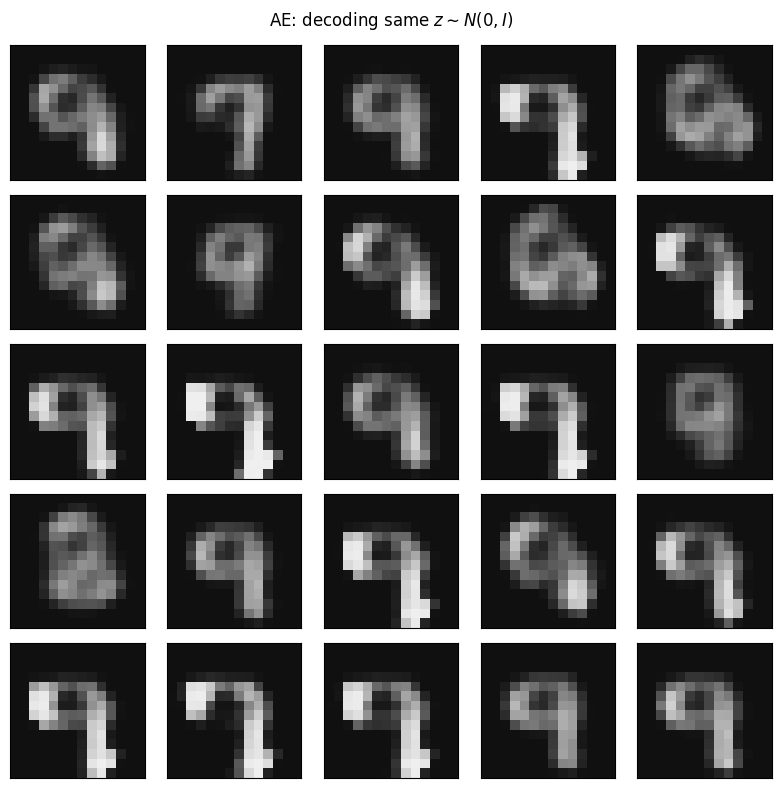

In [31]:
# Exercise 11b: Decode standard-normal latent samples
seed_everything(SEED + 99)
num_samples = 25
z_common = torch.randn(num_samples, latent_dim).to(device)

with torch.no_grad():
    # Decode with VAE
    vae_logits = vae_model.decoder(z_common)
    vae_gen = vae_model.decoder.mean(vae_logits).cpu().view(-1, *data_dims)

    # Decode with AE
    ae_gen = ae_model.decode_mean(z_common).cpu().view(-1, *data_dims)

# Visualize VAE generations
plot_grid_of_mnist_samples(vae_gen, title='VAE: decoding $z \sim N(0, I)$')
plt.show()

# Visualize AE generations
plot_grid_of_mnist_samples(ae_gen, title='AE: decoding same $z \sim N(0, I)$')
plt.show()

While the inputs are identical, the results look different because the VAE was trained to map this specific distribution to the data space, whereas the deterministic AE has no such prior constraint.

### **Exercise 11c. Compare encoded latent distributions**

Plot the VAE encoder means and deterministic AE codes for the same test images. Add circles of radius $1$ and $3$ as a rough visual guide to the region occupied by a two-dimensional standard Gaussian.

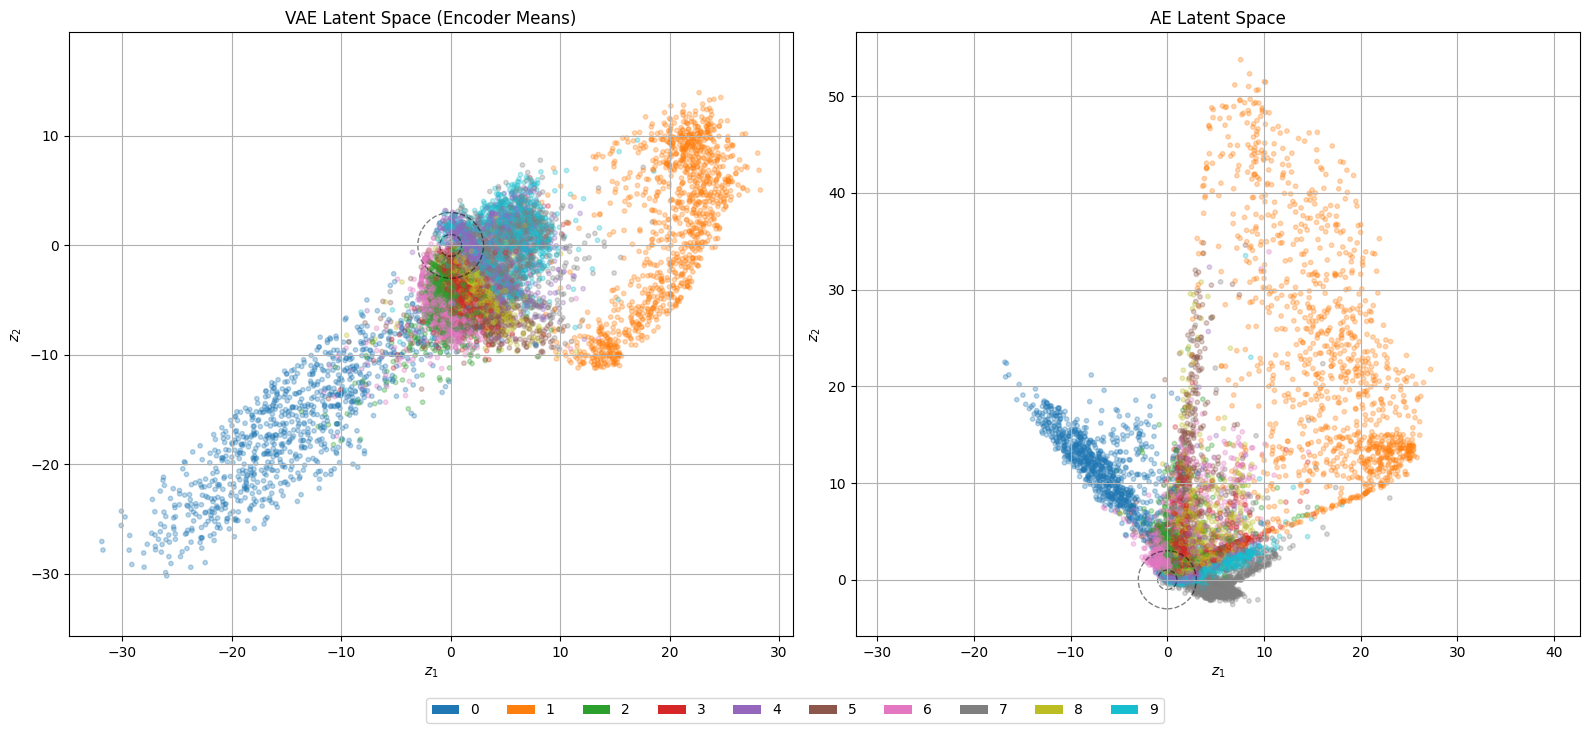

In [32]:
# Exercise 11c: Compare encoded latent distributions
@torch.inference_mode()
def encode_dataset_with_ae(model, dataset, *, batch_size):
    loader = create_dataloader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    latents = []
    labels = []
    for X, y in loader:
        X = flatten_images(X.to(device))
        z = model.encode(X)
        latents.append(z.cpu())
        labels.append(y.cpu())
    return torch.cat(latents), torch.cat(labels)

# Get latent representations
Z_vae, Y_test = encode_dataset_with_vae(vae_model, test_data_for_plots, batch_size=batch_size)
Z_ae, _ = encode_dataset_with_ae(ae_model, test_data_for_plots, batch_size=batch_size)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def plot_latent_space(ax, Z, title):
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    ax.scatter(Z[:, 0], Z[:, 1], c=np.asarray(colors)[Y_test.numpy()], alpha=0.3, s=10)

    # Add circles for N(0, I) guide
    for r in [1, 3]:
        circle = mpl.patches.Circle((0, 0), r, color='black', fill=False, linestyle='--', alpha=0.5)
        ax.add_patch(circle)

    ax.set_title(title)
    ax.set_xlabel('$z_1$')
    ax.set_ylabel('$z_2$')
    ax.grid(True)
    ax.set_aspect('equal', adjustable='datalim')

plot_latent_space(axes[0], Z_vae, 'VAE Latent Space (Encoder Means)')
plot_latent_space(axes[1], Z_ae, 'AE Latent Space')

# Shared legend
legend_elements = [mpl.patches.Patch(facecolor=colors[i], label=str(i)) for i in range(10)]
fig.legend(handles=legend_elements, loc='lower center', ncol=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()